In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import plotly.graph_objects as go
from scipy.ndimage import zoom
import cv2
from torchvision import transforms as T
import torchvision.transforms as T
import numpy as np
import os
import torch
from common import *
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import PIL
import PIL.Image
import cv2
from kemsekov_torch.positional_emb import PositionalEncodingPermute
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import affine_transform
import random
import skimage.measure
from scipy.ndimage import rotate
from scipy.spatial.transform import Rotation
from scipy.ndimage import gaussian_filter
from torch.cuda.amp import GradScaler, autocast



/home/alexus/Desktop/For_Generator/kemsekov_torch/__pycache__/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [2]:

class GeneratedDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, labels_dir, info_dir, images_transform=None, projections_order=['a', 'b']):
        super().__init__()
        
        self.projections_order = projections_order
        
        # Считываем разметку
        labels = os.listdir(labels_dir)
        index_to_label = {i.split('.')[0]: os.path.join(labels_dir, i) for i in labels}
        
        # Считываем изображения
        images = os.listdir(images_dir)
        image_labels = [i.split("image")[1].split(".")[0] for i in images]
        
        data = {}
        for image, label in zip(images, image_labels):
            label_index = label[:-1]
            label_letter = label[-1]
            if label_index not in data:
                data[label_index] = {}
            data[label_index][label_letter] = os.path.join(images_dir, image)
        
        # Добавляем метки и проекции
        for i in index_to_label:
            row = data[i]
            row['label'] = index_to_label[i]
            projections = [row[p] for p in projections_order]
            row['projections'] = projections
        
        # Загружаем углы проекций из info файлов
        self.angles = {}
        info_files = os.listdir(info_dir)
        for info_file in info_files:
            if info_file.endswith(".info.0"):  # Фильтруем нужные файлы
                info_path = os.path.join(info_dir, info_file)
                with open(info_path, 'r') as f:
                    info_data = json.load(f)
                case_id = info_file.split('.')[0]  # ID кейса
                self.angles[case_id] = {
                    'theta': info_data.get("theta_array", []),
                    'phi': info_data.get("phi_array", [])
                }
        
        self.data = data
        self.keys = list(self.data.keys())
        self.images_transform = images_transform if images_transform else lambda x: T.ToTensor()(x)
    
    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, index):
        key = self.keys[index]
        row = self.data[key]
        label = np.load(row['label'])
        images = [PIL.Image.open(v) for v in row['projections']]
        images = torch.concat([self.images_transform(i) for i in images])
        
        # Получаем углы для данного случая
        angles = self.angles.get(key, {'theta': [0] * len(self.projections_order), 'phi': [0] * len(self.projections_order)})
        theta = torch.tensor(angles['theta'], dtype=torch.float32)
        phi = torch.tensor(angles['phi'], dtype=torch.float32)
        
        return images, torch.tensor(label), theta, phi

In [3]:
# Пути к данным
images_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/images/test"
labels_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/labels/test/"
info_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/info/"

# Трансформации для проекций
def mean_channel(x):
    return x.mean(axis=0)[None, :]

def distance_transform(image_mask):
    image_mask = np.asarray(image_mask)[0]
    binary_mask = (image_mask > np.mean(image_mask)).astype(np.uint8)
    distance = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)
    return torch.tensor(image_mask + distance[None, :])

images_transform = T.Compose([
    T.ToTensor(),
    T.Lambda(mean_channel),
    T.Resize((128, 128)),
    T.Lambda(distance_transform),
])

# Загрузка данных
d2 = GeneratedDataset(images_dir, labels_dir, info_dir, images_transform=images_transform)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

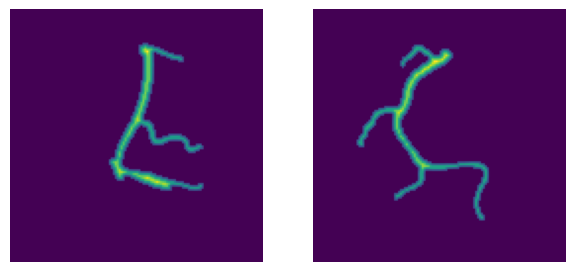

In [4]:
sample_index = 2 #random.randint(0,len(d)-1)
sample = d2[sample_index] #d2[1]
plt.figure(figsize=(15,15))
plt.subplot(1,4,1)
plt.imshow(sample[0][0]) #d2[1][0][0]
plt.axis('off')
plt.subplot(1,4,2)
plt.imshow(sample[0][1])
plt.axis('off')

In [5]:
images, label, theta, phi = d2[sample_index]
proj1 = images[0].cpu().numpy() #d2[1][0]
proj2 = images[1].cpu().numpy()
proj2.shape

(128, 128)

In [ ]:
def normalize_tensor(sample):
    centerline_copy = sample*1.0
    slice = centerline_copy[..., :3]
    scale = float(slice.max() - slice.min())

    centerline_copy[..., :3] -= slice.min()
    centerline_copy[..., :3] /= scale if scale != 0.0 else 1.0
    centerline_copy[..., -1] /= scale if scale != 0.0 else 1.0
    return centerline_copy

@torch.compile
def create_shadow(projection, phi, theta, volume_shape=(128, 128, 128)):
    D_x, D_y, D_z = volume_shape

    projection = torch.tensor(projection, dtype=torch.float32)
    h, w = projection.shape
    vol = torch.zeros(volume_shape, dtype=torch.float32)
    x0, y0 = (D_x - w) // 2, (D_y - h) // 2
    vol[y0:y0+h, x0:x0+w, 0] = projection
    y_coords, x_coords = torch.where(vol[:, :, 0] > 0)
    intensities = vol[y0:y0+h, x0:x0+w, 0][y_coords - y0, x_coords - x0]
    
    phi = torch.tensor(phi)
    theta = torch.tensor(theta)
    
    phi_rad, theta_rad = torch.tensor(torch.deg2rad(phi)), torch.tensor(torch.deg2rad(theta))
    dx = torch.sin(theta_rad) * torch.cos(phi_rad)
    dy = torch.sin(theta_rad) * torch.sin(phi_rad)
    dz = -torch.cos(theta_rad)
    norm = torch.sqrt(dx**2 + dy**2 + dz**2)
    dx, dy, dz = dx / norm, dy / norm, dz / norm
    z_indices = torch.arange(D_z, dtype=torch.long)
    shadow_x = x_coords[:, None] + dx * z_indices[None, :]
    shadow_y = y_coords[:, None] + dy * z_indices[None, :]
    shadow_z = z_indices[None, :].repeat(len(x_coords), 1)
    shadow_x = shadow_x.round().long().clamp(0, D_x - 1)
    shadow_y = shadow_y.round().long().clamp(0, D_y - 1)
    shadow_z = shadow_z.clamp(0, D_z - 1)
    for i in range(len(x_coords)):
        for j in range(D_z):
            if shadow_z[i, j] < D_z:
                vol[shadow_y[i, j], shadow_x[i, j], shadow_z[i, j]] = intensities[i]
    return vol

@torch.compile
def create_shadow1(projection, phi, theta, volume_shape=(128, 128, 128)):
    D_x, D_y, D_z = volume_shape

    projection = torch.tensor(projection, dtype=torch.float32)
    h, w = projection.shape
    vol = torch.zeros(volume_shape, dtype=torch.float32)
    x0, y0 = (D_x - w) // 2, (D_y - h) // 2
    vol[y0:y0+h, x0:x0+w, 0] = projection
    y_coords, x_coords = torch.where(vol[:, :, 0] > 0)
    intensities = vol[y0:y0+h, x0:x0+w, 0][y_coords - y0, x_coords - x0]
    
    phi = torch.tensor(phi)
    theta = torch.tensor(theta)
    
    phi_rad, theta_rad = torch.tensor(torch.deg2rad(phi)), torch.tensor(torch.deg2rad(theta))
    dx = torch.sin(theta_rad) * torch.cos(phi_rad)
    dy = torch.sin(theta_rad) * torch.sin(phi_rad)
    dz = -torch.cos(theta_rad)
    norm = torch.sqrt(dx**2 + dy**2 + dz**2)
    dx, dy, dz = dx / norm, dy / norm, dz / norm
    z_indices = torch.arange(D_z, dtype=torch.long)
    shadow_x = x_coords[:, None] + dx * z_indices[None, :]
    shadow_y = y_coords[:, None] + dy * z_indices[None, :]
    shadow_z = z_indices[None, :].repeat(len(x_coords), 1)
    shadow_x = shadow_x.round().long().clamp(0, D_x - 1)
    shadow_y = shadow_y.round().long().clamp(0, D_y - 1)
    shadow_z = shadow_z.clamp(0, D_z - 1)
    for j in range(D_z):
        i_mask = shadow_z[:, j] < D_z
        vol[shadow_y[i_mask, j], shadow_x[i_mask, j], shadow_z[i_mask, j]] = intensities[i_mask]
    return vol

In [ ]:
from typing import List


def create_output_model(output_3d_model : torch.Tensor, volume_shape : List[int]):
    output_3d_model = normalize_tensor(output_3d_model)    
    T = torch.zeros(volume_shape, dtype=torch.float32)

    for group in range(output_3d_model.shape[0]):
        x = (output_3d_model[group, :, 0] * 100 + 10).int().clip(0, 127)
        y = (output_3d_model[group, :, 1] * 100 + 10).int().clip(0, 127)
        z = (output_3d_model[group, :, 2] * 100 + 10).int().clip(0, 127)
        R = torch.tensor(output_3d_model[group, :, 3], dtype=torch.float32) * 10
        # print(f"Group {group} R min, max:", R.min().item(), R.max().item())
        for i in range(len(x)):
            radius = int((R[i] * 12).clamp(1, 10))
            x_grid, y_grid, z_grid = torch.meshgrid(
                torch.arange(-radius, radius + 1),
                torch.arange(-radius, radius + 1),
                torch.arange(-radius, radius + 1)
            )
            mask = (x_grid ** 2 + y_grid ** 2 + z_grid ** 2 <= radius ** 2)
            x_shifted = x[i] + x_grid[mask]
            y_shifted = y[i] + y_grid[mask]
            z_shifted = z[i] + z_grid[mask]
            valid = (x_shifted >= 0) & (x_shifted < 128) & (y_shifted >= 0) & (y_shifted < 128) & (z_shifted >= 0) & (z_shifted < 128)
            x_valid, y_valid, z_valid = x_shifted[valid], y_shifted[valid], z_shifted[valid]


            insertion_index =  T[x_valid, y_valid, z_valid] == 0
            average_index    = T[x_valid, y_valid, z_valid] != 0

            T[x_valid, y_valid, z_valid] += R[i]*insertion_index
            
            avg = (R[i]+T[x_valid, y_valid, z_valid])/2
            
            T[x_valid, y_valid, z_valid] +=  (avg-T[x_valid, y_valid, z_valid]) * average_index

            # T[insertion_index]=R[i]
            # T[average_index]=(T[average_index]+R[i])/2

            # for x_v, y_v, z_v in zip(x_valid, y_valid, z_valid):
            #     if T[x_v, y_v, z_v] == 0:
            #         T[x_v, y_v, z_v] = R[i]
            #     else:
            #         T[x_v, y_v, z_v] = (T[x_v, y_v, z_v] + R[i]) / 2
    return T


In [129]:
def get_3d_tensors(projection1,projection2,correct_3d_geometry  ,tensor_output_shape=[128,128,128]):
    """
    Из двух двумерных проекций `projection1` (1,128,128), `projection2` (1,128,128) строит трехмерный тензор размером `tensor_output_shape` который содержит в себе тени от
    двумерных проекций.

    Из информации о ветках `correct_3d_geometry` (4,300,4) строит 3д тензор

    Возвращает два 3д тенозора размером `volume_shape`, первый из которых - тензор теней, второй - тензор с 3д геометрией
    """

    phi1, phi2, theta1, theta2 = -40.0, 75.0, -10.0, -10.0
    
    D_x, D_y, D_z = tensor_output_shape
    # Убедимся, что проекция — бинарная (0 или 1)
    #projection = (projection > 0).float()  # На случай, если остались небольшие значения
    # Масштабируем проекцию до размеров D_x, D_y

    projection1 = zoom(projection1.cpu(), (D_x / projection1.shape[0], D_y / projection1.shape[1]), order=1)
    projection2 = zoom(projection2.cpu(), (D_x / projection2.shape[0], D_y / projection2.shape[1]), order=1)

    projection1=torch.tensor(projection1).to(projection1.device)
    projection2=torch.tensor(projection2).to(projection2.device)

    shadow1 = create_shadow1(projection1, phi1, theta1, tensor_output_shape)
    shadow2 = create_shadow1(projection2, phi2, theta2, tensor_output_shape)
    backprojection = torch.stack([shadow1,shadow2])

    T = create_output_model(correct_3d_geometry.to(projection1.device), volume_shape = tensor_output_shape)
    return backprojection, T

backprojection, T = get_3d_tensors(sample[0][0].cuda(),sample[0][1].cuda(),sample[1].cuda())

/tmp/ipykernel_20330/2837425872.py:60: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

/tmp/ipykernel_20330/2252635295.py:12: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



tensor(0.2759)


In [134]:
# Визуализация target_3d, shadow1 и shadow2
def visualize_3d_volume(volume, title="3D Reconstruction"):
    nonzero_indices = (volume > 0.01).nonzero(as_tuple=False)
    if len(nonzero_indices) > 0:
        if len(nonzero_indices) > 10000:
            indices = torch.randperm(len(nonzero_indices))[:10000]
            nonzero_indices = nonzero_indices[indices]
        values = volume[nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]]
        x_coords = nonzero_indices[:, 0].tolist()
        y_coords = nonzero_indices[:, 1].tolist()
        z_coords = nonzero_indices[:, 2].tolist()
        radii = values.tolist()
        fig = go.Figure(data=[go.Scatter3d(
            x=x_coords, y=y_coords, z=z_coords, mode='markers',
            marker=dict(size=3, color=radii, colorscale='Viridis', opacity=0.8, colorbar=dict(title="Value"))
        )])
        fig.update_layout(
            title=title,
            scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode='cube'),
            width=700, height=700,
            template="plotly_dark"
        )
        fig.show()
    else:
        print(f"No significant nonzero values (> 0.001) in {title} to visualize!")

# Визуализация
print("Visualizing target_3d...")
visualize_3d_volume(T.squeeze().squeeze(), title="Original 3D Target")
print("Visualizing shadow1...")
visualize_3d_volume(backprojection[0], title="Shadow 1")


Visualizing target_3d...


Visualizing shadow1...


In [ ]:
class BackprojectionDataset(torch.utils.data.Dataset):
    def __init__(self,two_proj_3d_dataset):
        super().__init__()
        self.two_proj_3d_dataset=two_proj_3d_dataset
    def __len__(self):
        return len(self.two_proj_3d_dataset)
    def __getitem__(self, index):
        
        sample = self.two_proj_3d_dataset[index]
        #sample[0] is two 2d projections
        #sample[1] is 3d

        # construct two 3d tensors
        # return
        return get_3d_tensors(...)
